In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torch import optim
import dlc_practical_prologue as prologue
import time

In [2]:
# good, but a lot of overfitting (0.955/ 0.763 after 25 epochs, 10 rounds)
class NetTest(nn.Module):
    def __init__(self):
        super(NetTest, self).__init__()
        self.conv1 = nn.Conv2d(2, 64, kernel_size=5)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(512, 20)
        self.fc2 = nn.Linear(20, 2)


    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.conv3(x)
        x = F.relu(x)
        x = self.conv4(x)
        x = F.relu(x)
        x = self.fc1(x.view(-1, 512))
        x = F.relu(x)
        x = self.fc2(x)
        return x, None

In [3]:
# 0.636/ 0.604 after 25 epochs, 10 rounds
class NetTestMax(nn.Module):
    def __init__(self):
        super(NetTestMax, self).__init__()
        self.conv1 = nn.Conv2d(2, 64, kernel_size=5)
        self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=2)
        self.max_pool2 = nn.MaxPool2d(kernel_size=3, stride=1)
        self.fc1 = nn.Linear(512, 20)
        self.fc2 = nn.Linear(20, 2)


    def forward(self, x):
        x = self.conv1(x)
        x = self.max_pool1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.max_pool2(x)
        x = F.relu(x)
        x = self.fc1(x.view(-1, 512))
        x = F.relu(x)
        x = self.fc2(x)
        return x, None

In [4]:
# 0.943 / 0.800 after 200 epochs, 1 round
class NetTestDropout(nn.Module):
    def __init__(self):
        super(NetTestDropout, self).__init__()
        self.conv1 = nn.Conv2d(2, 64, kernel_size=5)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=2)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(512, 20)
        self.fc2 = nn.Linear(20, 2)
        self.drop2d = nn.Dropout2d(0.1)
        self.dropInput = nn.Dropout(0.6)
        self.drop = nn.Dropout(0.4)


    def forward(self, x):
        x = self.dropInput(x)
        x = self.conv1(x)
        x = self.drop2d(x) # dropout
        x = F.relu(x)
        x = self.conv2(x)
        x = self.drop2d(x) # dropout
        x = F.relu(x)
        x = self.conv3(x)
        x = self.drop2d(x) # dropout
        x = F.relu(x)
        x = self.conv4(x)
        x = self.drop2d(x) # dropout
        x = F.relu(x)
        x = self.drop(x.view(-1, 512)) # dropout
        x = self.fc1(x)
        x = self.drop(x) # dropout
        x = F.relu(x)
        x = self.fc2(x)
        return x, None

In [153]:
# works well, but with 0 aux loss coeff ()
class NetAuxLoss(nn.Module):
    def __init__(self):
        super(NetAuxLoss, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4)
        self.maxpool1= nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=1)
        self.fc1 = nn.Linear(64, 10)
        self.fc2 = nn.Linear(20, 20)
        self.fc3 = nn.Linear(20, 20)
        self.fc4 = nn.Linear(20, 2)

    def forward(self, x):
        
        x1 = x[:,0:1,:,:]
        x2 = x[:,1:2,:,:]
        
        x1 = self.conv1(x1)
        x1 = self.maxpool1(x1)
        x1 = F.relu(x1)
        x1 = self.conv2(x1)
        x1 = self.maxpool2(x1)
        x1 = F.relu(x1)
        x_aux1 = self.fc1(x1.view(-1, 64))
        
        x2 = self.conv1(x2)
        x2 = self.maxpool1(x2)
        x2 = F.relu(x2)
        x2 = self.conv2(x2)
        x2 = self.maxpool2(x2)
        x2 = F.relu(x2)
        x_aux2 = self.fc1(x2.view(-1, 64))
        
        x_fin = torch.cat((F.relu(x_aux1), F.relu(x_aux2)), 1)
        
        x_fin = self.fc2(x_fin)
        x_fin = F.relu(x_fin)
        x_fin = self.fc3(x_fin)
        x_fin = F.relu(x_fin)
        x_fin = self.fc4(x_fin)
        x_fin = F.relu(x_fin)
        
        return x_fin, x_aux1, x_aux2

In [125]:
# works well, but with 0 aux loss coeff ()
class NetMnist(nn.Module):
    def __init__(self):
        super(NetMnist, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4)
        self.maxpool1= nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=1)
        self.fc1 = nn.Linear(64, 10)

    def forward(self, x):
        
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        x = F.relu(x)
        x = self.fc1(x.view(-1, 64))
        
        return x, None, None

In [129]:
# return the accuracy between predicted and groundtruth, convert predicted values to {0, 1}
def accuracy(model, test_input, test_target, one_digit=False):
    nb_samples = test_input.shape[0]
    model.train(False) # deactivate dropout
    output = model(test_input)[0]
    model.train(True) # activate dropout
    output_int = torch.zeros(nb_samples)
    for i in range(nb_samples):
        if one_digit:
            _, pred_class = output[i].max(0)
            output_int[i] = pred_class
        else:
            if output[i][0] <= output[i][1]: # first digit lesser or equal
                output_int[i] = 1
    nb_errors = (output_int - test_target).type(torch.BoolTensor).sum().item()
    return (nb_samples - nb_errors) / nb_samples

In [130]:
def one_hot_classes(classes):
    nb_samples = classes.shape[0]
    one_hot = torch.zeros(nb_samples, 10)
    for i in range(nb_samples):
        one_hot[i, classes[i]] = 1
    return one_hot.type(torch.LongTensor)

In [131]:
def weight_reset(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        m.reset_parameters()

In [171]:
# Train a model, print the results and return the train and validation loss.
def train_model(model, rounds, validation=True, verbose=False, one_digit=False):
                
    batch_size, nb_epochs = 100, 25
    
    nb_epochs_shown = 10
    
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.Adam(model.parameters(), lr = 1e-3)
    
    # tensors for averaging over the rounds
    times = torch.zeros(rounds)
    train_acc = torch.zeros(rounds)
    test_acc = torch.zeros(rounds)
    train_loss = torch.zeros(rounds, nb_epochs + 1)
    test_loss = torch.zeros(rounds, nb_epochs + 1)
    
    for r in range(rounds):
        
        # new data
        train_input, train_target, train_classes, test_input, test_target, test_classes = prologue.generate_pair_sets(nb=1000)
        
        if one_digit:
            train_input = train_input[:,0:1,:,:]
            #train_target = one_hot_classes(train_classes[:,0])
            train_target = train_classes[:,0]
            test_input = test_input[:,0:1,:,:]
            #test_target = one_hot_classes(test_classes[:,0])
            test_target = test_classes[:,0]
        
        # reset weights
        model.apply(weight_reset) 
        
        t0 = time.time()

        for e in range(nb_epochs):
            
            # store the train and validation loss for each epoch and round 
            if validation:
                model.train(False) # deactivate dropout
                train_loss[r,e] = criterion(model(train_input)[0], train_target)
                test_loss[r,e] = criterion(model(test_input)[0], test_target)
                model.train(True) # activate dropout
            
            # updating the model
            for input, targets, classes in zip(train_input.split(batch_size), 
                                               train_target.split(batch_size), 
                                               train_classes.split(batch_size)):
                
                output = model(input)
                
                loss = criterion(output[0], targets)
                
                # use of auxilliary losses
                if output[1] is not None and output[2] is not None:
                    c_aux = 0 # coeff for auxilliary losses
                    c_final = 1 # coeff for final loss
                    loss_aux1 = criterion(output[1], classes[:,0])
                    loss_aux2 = criterion(output[2], classes[:,1])
                    loss = c_final * loss + c_aux * (loss_aux1 + loss_aux2)
                    
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # print the loss for a given number of epochs - used for direct feedback
            if verbose:
                if((e + 1) % int(nb_epochs / nb_epochs_shown) == 0):
                    print("Epoch {} | Train loss : {}".format(e+1, loss))
                    
        # final loss            
        if validation:
            model.train(False) # deactivate dropout
            train_loss[r,nb_epochs] = criterion(model(train_input)[0], train_target)
            test_loss[r,nb_epochs] = criterion(model(test_input)[0], test_target)
            model.train(True) # activate dropout

        t1 = time.time()
        
        times[r] = t1-t0
        train_acc[r] = accuracy(model, train_input, train_target, one_digit)
        test_acc[r] = accuracy(model, test_input, test_target, one_digit)
        
        print('Round {} done.'.format(r))
        
    print('--------------')
    
    total_trained_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print("Model : {} \n".format(model.__class__.__name__ ) + \
          "Number of trained parameters : {} \n".format(total_trained_params) + \
          "Size of mini-batches : {}\n".format(batch_size) + \
          "Averaged on {} rounds \n".format(rounds) + \
          "    Time for {} epochs : {:.2f}s\n".format(nb_epochs, times.mean().item()) + \
          "    Train accuracy : {:.3f} +- {:.3f}\n".format(train_acc.mean().item(), train_acc.std().item()) + \
          "    Test accuracy : {:.3f} +- {:.3f}".format(test_acc.mean().item(), test_acc.std().item()))
    
    return train_loss.detach().mean(dim=0), test_loss.detach().mean(dim=0)

In [174]:
#model = NetTestMax()
#model = NetTest()
#model = NetTestDropout()
#model = NetAuxLoss()
model = NetMnist()
avg_train_loss, avg_test_loss = train_model(model, rounds=10, verbose=True, validation=False, one_digit=True)

Epoch 2 | Train loss : 1.9693294763565063
Epoch 4 | Train loss : 0.4445190131664276
Epoch 6 | Train loss : 0.46778908371925354
Epoch 8 | Train loss : 0.2595830261707306
Epoch 10 | Train loss : 0.20493216812610626
Epoch 12 | Train loss : 0.2527382969856262
Epoch 14 | Train loss : 0.2466762214899063
Epoch 16 | Train loss : 0.19919677078723907
Epoch 18 | Train loss : 0.10771114379167557
Epoch 20 | Train loss : 0.08878060430288315
Epoch 22 | Train loss : 0.03179403394460678
Epoch 24 | Train loss : 0.015123873949050903
Round 0 done.
Epoch 2 | Train loss : 3.7683255672454834
Epoch 4 | Train loss : 1.958755612373352
Epoch 6 | Train loss : 1.5637688636779785
Epoch 8 | Train loss : 1.1833148002624512
Epoch 10 | Train loss : 0.8919852375984192
Epoch 12 | Train loss : 0.6733393669128418
Epoch 14 | Train loss : 0.5238969922065735
Epoch 16 | Train loss : 0.40254664421081543
Epoch 18 | Train loss : 0.2914164960384369
Epoch 20 | Train loss : 0.21491779386997223
Epoch 22 | Train loss : 0.2714477181434

In [165]:
# JUST FOR VISUALIZATION
import matplotlib.pyplot as plt
import numpy as np

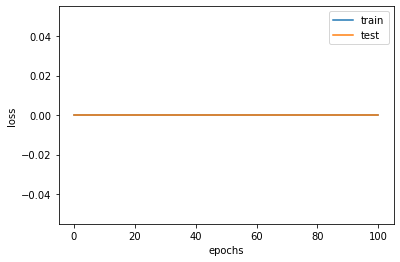

In [166]:
# Visualization of the loss over the epochs
fig, ax = plt.subplots(figsize=(6, 4))

plt.plot(avg_train_loss, label='train')
plt.plot(avg_test_loss, label='test')

nb_epochs = avg_train_loss.shape[0]
#ax.set_xticks([])
#ax.set_xticks(np.arange(nb_epochs))
#ax.set_xticklabels(np.arange(nb_epochs) + 1)

ax.legend()
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

In [58]:
train_input, train_target, train_classes, test_input, test_target, test_classes = prologue.generate_pair_sets(nb=1000)

train_input = train_input[:,0:1,:,:]
train_target = one_hot_classes(train_classes[:,0])
test_input = test_input[:,0:1,:,:]
test_target = one_hot_classes(test_classes[:,0])

In [59]:
train_target

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [0, 0, 1,  ..., 0, 0, 0],
        [0, 0, 1,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 1, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])